In [1]:
import sys 
sys.path.append("..")
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from utils.utility import *
from utils.models_arch import *
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Stage 2: Latent Space Refinement Autoencoder

## Overview
This notebook trains a second sparse autoencoder on the latent representations learned by Stage 1.

**Goal**: Further refine the 32-dimensional latent space for better feature hierarchies

**Data Flow**:
```
Unlabeled Dataset (60,000 samples)
    ↓
Stage 1 Encoder: (N,8) → (N,32) latent features
    ↓
Save Latent Dataset: coordinates + 32-dim features to HDF5
    ↓
Stage 2 Encoder: (N,32) → (N,64) refined latent features
    ↓
Stage 2 Decoder: (B,64) → (B,32) reconstruction [MSE loss]
    ↓
Saves Encoder2 for Stage 3 (classification)
```

## Why a Second Autoencoder?

1. **Hierarchical Learning**: Encoder1 learns initial abstract features from raw data
2. **Latent Refinement**: Encoder2 learns higher-level patterns in latent space
3. **Better Representations**: Two-stage encoding captures multi-scale information
4. **Transfer Learning**: Pretrained encoders provide strong initialization for classifier

**Analogy**: 
- Stage 1: Learn low-level details (edges, textures)
- Stage 2: Learn high-level structure (objects, patterns) using Stage 1 features

In [85]:
latent_h5_path = "data/latent.h5"

with h5py.File(latent_h5_path, "r") as f:
    print("coords:", f["coords"].shape)
    print("feats :", f["feats"].shape)
    print("sizes :", f["sizes"].shape)

coords: (24668769, 3)
feats : (24668769, 32)
sizes : (60000,)


## Part 1: Latent Dataset Overview

**Source**: latent.h5 created by Stage 1
- Contains sparse coordinates and 32-dimensional features for all 60,000 samples
- Total sparse sites: ~24.6 million (variable per sample)
- Custom dataset class handles lazy loading to manage memory

**Key insight**: Encoder1 already compressed the spatial information (~4000→~400 sites per sample after pooling)
Now we work in this more abstract space to learn even higher-level features.

In [86]:
class LatentSparseDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path

        with h5py.File(self.h5_path, "r") as f:
            self.sizes = f["sizes"][:]

        self.offsets = [0]
        for s in self.sizes:
            self.offsets.append(self.offsets[-1] + int(s))

        self._f = None
        self._coords = None
        self._feats = None

    def _ensure_open(self):
        if self._f is None:
            self._f = h5py.File(self.h5_path, "r")
            self._coords = self._f["coords"]
            self._feats = self._f["feats"]

    def __len__(self):
        return len(self.sizes)

    def __getitem__(self, idx):
        self._ensure_open()

        start = self.offsets[idx]
        end = self.offsets[idx + 1]

        coords = torch.from_numpy(self._coords[start:end])
        feats = torch.from_numpy(self._feats[start:end])

        coords = coords.clone()
        coords[:, 0] = 0

        return coords, feats

In [87]:
def latent_sparse_collate(batch):
    all_coords = []
    all_feats = []
    sizes = []

    for b, (coords_i, feats_i) in enumerate(batch):
        sizes.append(coords_i.shape[0])

        coords_i = coords_i.clone()
        coords_i[:, 0] = b

        all_coords.append(coords_i)
        all_feats.append(feats_i)

    coords = torch.cat(all_coords, dim=0)
    feats = torch.cat(all_feats, dim=0)

    return coords, feats, sizes

In [88]:
latent_ds = LatentSparseDataset(latent_h5_path)

latent_dl = DataLoader(
    latent_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    collate_fn=latent_sparse_collate,
    pin_memory=True
)

coords2, feats2, sizes2 = next(iter(latent_dl))
print(coords2.shape, feats2.shape, len(sizes2))

torch.Size([3333, 3]) torch.Size([3333, 32]) 8


In [95]:
target = sparse_global_mean_pool(coords2, feats2, batch_size = 8)

## Part 2: Encoder2 Architecture

**Input**: Latent representations from Encoder1
- Sparse coordinates from latent space
- Features dimension: 32 (from Encoder1)

**Architecture**:
```
Input: (N,32) features at sparse coordinates
    ↓
Single VGG Stage: 3× [VSC 3×3 (32→64) + BatchNorm + ReLU]
    ↓ (spatial pooling for downsampling)
Global Mean Pool: Over spatial sites → (B,64)
    ↓
Decoder MLP: 64 → 128 → 32
    ↓
Output: (B,32) - reconstructs Encoder1 latent mean
```

**Why only one stage in Encoder2?**
- Input is already hierarchical (from Encoder1 pooling)
- Fewer spatial sites (~400 vs ~1000 in Encoder1 input)
- Single stage is sufficient to learn refined representations
- Reduces computation while still capturing hierarchical patterns

**Channel progression**: 32 → 64
- Increases model capacity to capture patterns in latent space
- Creates bottleneck: 32D → 64D → 32D for regularization

In [96]:
def train_ae2_one_epoch(model, loader, optimizer, device, max_batches=None, accum_steps=4):
    model.train()
    total_loss = 0.0
    total_batches = 0

    optimizer.zero_grad()

    for batch_idx, (coords, feats, sizes) in enumerate(loader):
        coords = coords.to(device, non_blocking=True)
        feats = feats.float().to(device, non_blocking=True)

        batch_size = len(sizes)
        target = sparse_global_mean_pool(coords, feats, batch_size)

        pred, coords2, z2, z2_global = model(coords, feats, batch_size=batch_size)

        raw_loss = nn.functional.mse_loss(pred, target)
        loss = raw_loss / accum_steps
        loss.backward()

        if (batch_idx + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        total_loss += raw_loss.item()
        total_batches += 1

        if batch_idx % 100 == 0:
            print(f"batch {batch_idx}: loss = {raw_loss.item():.6f}")

        if max_batches is not None and batch_idx + 1 >= max_batches:
            break

    if total_batches % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    return total_loss / max(total_batches, 1)

In [97]:
ae2 = AutoEncoder2().to(device)
optimizer = optim.Adam(ae2.parameters(), lr=1e-3)

epoch_losses = []

for epoch in range(10):
    avg_loss = train_ae2_one_epoch(
        ae2,
        latent_dl,
        optimizer,
        device,
        max_batches=1000,
        accum_steps=4
    )
    epoch_losses.append(avg_loss)
    print(f"epoch {epoch}: avg_loss = {avg_loss:.6f}")

batch 0: loss = 0.087876
batch 100: loss = 0.006647
batch 200: loss = 0.002882
batch 300: loss = 0.002439
batch 400: loss = 0.002175
batch 500: loss = 0.001661
batch 600: loss = 0.001068
batch 700: loss = 0.001738
batch 800: loss = 0.002000
batch 900: loss = 0.001016
epoch 0: avg_loss = 0.004615
batch 0: loss = 0.000862
batch 100: loss = 0.008038
batch 200: loss = 0.001174
batch 300: loss = 0.000981
batch 400: loss = 0.001126
batch 500: loss = 0.001737
batch 600: loss = 0.000836
batch 700: loss = 0.000903
batch 800: loss = 0.000903
batch 900: loss = 0.000594
epoch 1: avg_loss = 0.001151
batch 0: loss = 0.000533
batch 100: loss = 0.000468
batch 200: loss = 0.000699
batch 300: loss = 0.000680
batch 400: loss = 0.000533
batch 500: loss = 0.000841
batch 600: loss = 0.000570
batch 700: loss = 0.000846
batch 800: loss = 0.000950
batch 900: loss = 0.001365
epoch 2: avg_loss = 0.000728
batch 0: loss = 0.000585
batch 100: loss = 0.000363
batch 200: loss = 0.001151
batch 300: loss = 0.000346
bat

## Part 3: AutoEncoder2 Training

**Training Objective**:
Reconstruct the global mean of Encoder1 latents using Encoder2 features

```
Sample: sparse (coords, z1_features)
    ↓
Encoder2: sparse features → (B,64) global pool
    ↓
Decoder2: (B,64) → (B,32) prediction
    ↓
Target: global_mean_pool(z1_features) = (B,32)
    ↓
Loss: MSE(predicted, target)
```

**Training Configuration**:
- **Loss**: L2 MSE (simple - no weighting needed in latent space)
- **Optimizer**: Adam (lr=1e-3)
- **Batch size**: 8 samples
- **Gradient accumulation**: 4 steps (effective batch=32)
- **Epochs**: 10
- **Data loading**: 2 workers, pinned memory

**Why MSE instead of weighted MSE?**
- Latent space is learned representation, not raw data
- All dimensions equally important for reconstruction
- Prevents decoder from exploiting zero-valued regions

**Benefits of Encoder2**:
- Learns refined 64-dimensional intermediate representations
- Multi-scale hierarchical embedding ideal for classification
- Frozen encoders provide strong transfer learning backbone

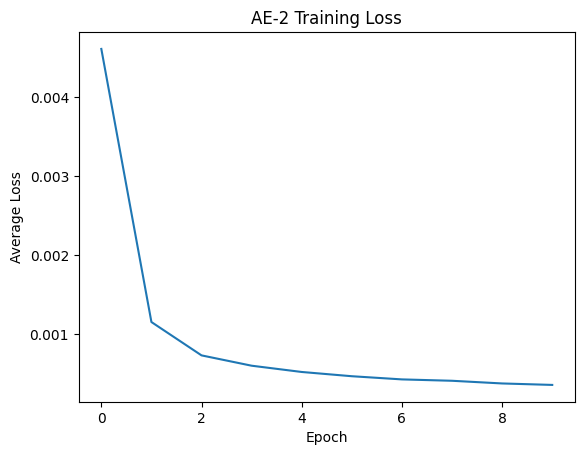

AttributeError: 'collections.OrderedDict' object has no attribute 'state_dict'

In [ ]:
import matplotlib.pyplot as plt

plt.plot(epoch_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("AE-2 Training Loss")
plt.show()
torch.save(ae2.state_dict(), "models/ae2_trained.pth")
print("AE2 saved.")

ae2 = torch.load("models/ae2_trained.pth")